In [15]:
import os
dataset_dir = r'C:\projects\SE4050-Deep-Learning-Assignment\data'
print("Contents of data folder:", os.listdir(dataset_dir))

Contents of data folder: ['.gitkeep', 'Testing', 'Training']


In [14]:
%pip install tensorflow

  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/384.1 MB 1.5 MB/s eta 0:04:10
   ---------------------------------------- 0.8/384.1 MB 1.5 MB/s eta 0:04:13
   ---------------------------------------- 1.0/384.1 MB 1.4 MB/s eta 0:04:34
   ---------------------------------------- 1.3/384.1 MB 1.4 MB/s eta 0:04:25
   ---------------------------------------- 1.6/384.1 MB 1.5 MB/s eta 0:04:18
   ---------------------------------------- 1.8/384.1 MB 1.5 MB/s eta 0:04:14
   ---------------------------------------- 2.4/384.1 MB 1.5 MB/s eta 0:04:08
   ---------------------------------------- 2.9/384.1 MB 1.7 MB/s eta 0:03:51
   ---------------------------------------- 3.4/384.1 MB 1.8 MB/s eta 0:03:37
   ---------------------------------------- 3.9/384.1 MB 1.8 MB/s eta 0:03:28
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
train_dir = r'..\data\Training'
test_dir = r'..\data\Testing'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training dataset and  Validation split (80% Training, 20% Validation)
train_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test dataset load seperatly
test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Class names
class_names = train_dataset.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Performance Optimization (Data traffic to GPU quickly)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 2. creating Custom CNN Model  (Baseline Model)
num_classes = 4

model_1 = models.Sequential([
    # Pixel values (0-255) normalization (0-1)
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Prevent overfitting
    layers.Dense(num_classes, activation='softmax')
])

# Checking the model structure
model_1.summary()

c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model 1 Compile
model_1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Training for 10 Epochs
EPOCHS = 10

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10


c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 637ms/step - accuracy: 0.6781 - loss: 0.8019 - val_accuracy: 0.8268 - val_loss: 0.4571
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 625ms/step - accuracy: 0.8266 - loss: 0.4619 - val_accuracy: 0.8884 - val_loss: 0.3111
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 102s 729ms/step - accuracy: 0.8788 - loss: 0.3287 - val_accuracy: 0.8875 - val_loss: 0.2797
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 108s 771ms/step - accuracy: 0.9170 - loss: 0.2247 - val_accuracy: 0.9116 - val_loss: 0.2327
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 103s 738ms/step - accuracy: 0.9391 - loss: 0.1753 - val_accuracy: 0.9134 - val_loss: 0.2221
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 107s 765ms/step - accuracy: 0.9545 - loss: 0.1218 - val_accuracy: 0.9330 - val_loss: 0.1829
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 809ms/step - accuracy: 0.9676 - loss: 0.0859 - val_accuracy: 0.9357 - val_loss: 0.1957
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 741ms/step - accuracy: 0.9746 - loss: 0.0723

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.75      0.82       400
  meningioma       0.85      0.82      0.83       400
     notumor       0.83      0.99      0.90       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



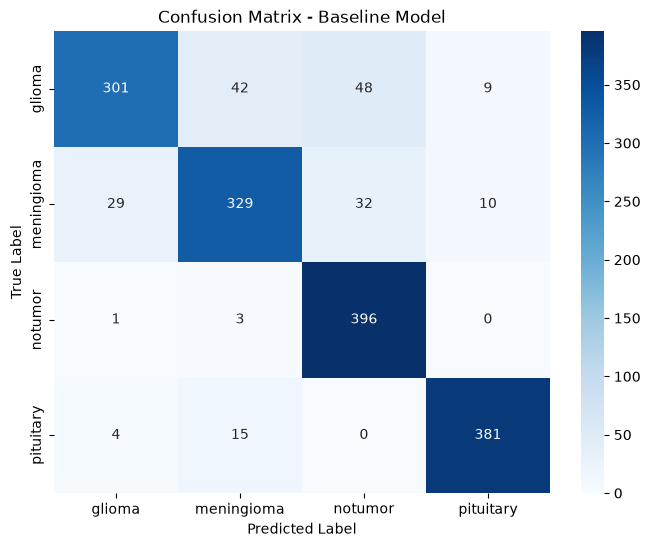

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on the Test dataset
Y_pred = model_1.predict(test_dataset)
y_pred = np.argmax(Y_pred, axis=1)

# True labels from the Test dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Model')
plt.show()

In [19]:

model_1.save('baseline_custom_cnn.keras')